# Spatial disaggregation clim-method comparison — rsds in Alaska

**Origin:** this comparison was prompted by [issue #547](https://github.com/carbonplan/srm-downscaling/issues/547), which reported implausibly high rsds at polar night at lat=64, lon=-149 — raw GCM output and both obs series stayed near zero while the downscaled/debiased output spiked. Diagnostic 2b below reproduces that exact point/season directly.

**Question:** for the near-zero-climatology "blow-up" problem in multiplicative spatial
disaggregation (see `[[project-modify-clipping-downscaling-tiny-threshold]]`), is
`disaggregation_clim_method="simple_rolling"` (a 31-day rolling mean of the day-of-year
climatology) a better fix than the current production fix — `disaggregation_tiny_threshold`
clipping (`1.0` W m-2 for rsds) — or some combination?

**"Better" is evaluated on two axes, per the user's framing:**
1. **Realism vs. observations** — does the method produce values that look like plausible
   weather, or does it introduce spurious extremes / bias relative to the fine-resolution
   obs record?
2. **Preservation of the GCM's projected differences** — does the method distort the
   climate-change signal (scenario − historical) that the debiased coarse GCM data implies,
   relative to a naive regrid of that same signal with no disaggregation-side smoothing/clipping?

**Methodology:** this notebook calls `downscale_from_coarse()` directly (bypassing the full
CLI/Coiled pipeline) on the same debiased-coarse inputs, once per candidate configuration,
so the only thing that differs between runs is the spatial-disaggregation step itself. This
mirrors the pattern already prototyped in
`docs/how-to/pipeline-stage-debugger-spatial-disaggregation.ipynb`. Everything runs against a
local debug icechunk store (`/tmp/bcsd-debug/`) — no S3 writes, no Coiled cluster; reads of
GCM/obs source data still go over the network for the Alaska subset only.

**Candidate configurations:**

| name | `disaggregation_method` | `clim_method` | `use_tiny_threshold` | `tiny_threshold` | role |
|---|---|---|---|---|---|
| `baseline` | `multiplicative` | `fft` | `False` | n/a | pre-fix behavior: shows the raw blow-up |
| `tiny_threshold` | `multiplicative` | `fft` | `True` | `1.0` | current production fix |
| `simple_rolling` | `multiplicative` | `simple_rolling` | `False` | n/a | candidate alt fix |
| `additive` | `additive` | `fft` | `False` | n/a | bonus reference: sidesteps division-by-near-zero entirely |
| `simple_rolling_plus_tiny_threshold` | `multiplicative` | `simple_rolling` | `True` | `1.0` | belt-and-suspenders: does the safety-net threshold add anything once smoothing already reduces how often it needs to fire? |

`use_tiny_threshold=False` — not `tiny_threshold=0.0` with the flag left on — is how `baseline`
and `simple_rolling` reproduce "no threshold fix applied." This matters mechanically: with the
flag on, the near-zero guard is `obs_coarse_doy_means < tiny_threshold` (strict `<`), so
`tiny_threshold=0.0` never catches a coarse climatology that is *exactly* zero (a real occurrence
for pr's dry season/dry days) and the residual division blows up to `inf`/`NaN` instead of being
capped. With the flag off, the function takes its other, always-present guard —
`obs_coarse_doy_means == 0` — which explicitly zeros the residual on exact-zero climatology days
instead of dividing by them, while leaving every other near-zero (but nonzero) day to blow up
uncapped except by `max_residual=100`. That uncapped blow-up *is* the pre-fix behavior we want
`baseline` to show; `tiny_threshold=0.0, use_tiny_threshold=True` is not a real production code
path (production only ever uses a positive threshold) and crashes on exact-zero climatology.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.downscaling_utils import (
    downscale_from_coarse,
    interpolate_coarse_to_fine_grid,
    subset_space,
)
from srm.pipeline import BCSDPipeline

warnings.filterwarnings("ignore", category=FutureWarning)

## Config

**Edit only this cell** to point the notebook at a different run.

In [ ]:
# ── Edit these values ──────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "rsds"
ENSEMBLE_MEMBER = "003"
SCENARIO = "SSP245"

# Alaska: matches configs/claire_tests subset_bounds exactly
SUBSET_BOUNDS = [55, 69, -154, -142]  # (lat_min, lat_max, lon_min, lon_max)
ROI_BOUNDS = [
    58,
    66,
    -151,
    -145,
]  # region actually reported on (trims any regrid-edge halo before diagnostics)

TRAIN_PERIOD_START = 1978
TRAIN_PERIOD_END = 2014
PREDICT_PERIOD_START = 2015
PREDICT_PERIOD_END = 2099

TINY_THRESHOLD_DEFAULT = 1.0  # bcsd_config.py BCSD_CONFIG['rsds']
DISAGG_METHOD_DEFAULT = "multiplicative"  # bcsd_config.py BCSD_CONFIG['rsds']
PLOT_SCALE = 1  # already W m-2, no conversion
UNITS_LABEL = "W m-2"  # raw, unscaled units — pair only with un-scaled values
PLOT_UNITS_LABEL = "W m-2"  # units after * PLOT_SCALE — pair with scaled values
# ──────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    downscaling_method="BCSD",
    train_period_start=TRAIN_PERIOD_START,
    train_period_end=TRAIN_PERIOD_END,
    predict_period_start=PREDICT_PERIOD_START,
    predict_period_end=PREDICT_PERIOD_END,
    subset_bounds=SUBSET_BOUNDS,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug-alaska-rsds",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")

## Load data and bias-correct (Stage 1 + 2 + 3 inputs)

Same as `pipeline-stage-debugger-spatial-disaggregation.ipynb` Stage 1–3, stopping short of
the spatial-disaggregation call itself — that's done manually below with each candidate
configuration.

In [ ]:
%%time
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
pipeline.prepare_observations(force=True)

In [ ]:
%%time
obs_coarse, obs_fine, model_hist = pipeline._load_gcm_obs()
# Eagerly load: these three are referenced repeatedly across nearly every diagnostic below
# (bias maps, point selection, chronological plots, delta reference, variability checks) —
# leaving them lazy would re-trigger the same read+regrid dask graph on every reference.
obs_coarse = obs_coarse.load()
obs_fine = obs_fine.load()
model_hist = model_hist.load()

In [ ]:
%%time
debiased_coarse_hist = pipeline._apply_bias_correction(obs_coarse, model_hist)

In [ ]:
%%time
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()
obs_coarse_s3 = obs_coarse_s3.load()
obs_fine_s3 = obs_fine_s3.load()
model_hist_s3 = model_hist_s3.load()
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)
debiased_coarse_scenario = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended
)

## Run spatial disaggregation under each candidate configuration

`allow_negative_values` is `False` for `baseline`/`tiny_threshold`/`simple_rolling`, matching
production (`pipeline.py:971`) — `False` only clips the *smoothed climatology term* inside
`calculate_doy_means`'s FFT branch to zero (`downscaling_utils.py:666-667`); it does **not**
clip the final `residuals + climatology` sum for either method. `additive` deliberately runs
with `allow_negative_values=True` instead — the most revealing, least-clipped setting — so
Diagnostic 1d below measures the *true* extent of negative output, not a partially-suppressed
version of it: if `additive` is quietly producing physically-impossible negative pr/rsds under
the hood even while its bias/distortion numbers look reasonable, that's a real defect worth
surfacing on its own, separate from whether it happens to preserve the mean/delta well.

`use_tiny_threshold` varies per method (see Config table above) — `baseline` and
`simple_rolling` set it `False` so the function's `obs_coarse_doy_means == 0` guard handles
exact-zero coarse climatology (replacing that residual with `0.0`) instead of the `< tiny_threshold`
guard, which would divide by zero when `tiny_threshold=0.0` and crash with a `NaNCheckError`.

In [ ]:
METHODS = {
    "baseline": dict(
        method=DISAGG_METHOD_DEFAULT,
        clim_method="fft",
        use_tiny_threshold=False,
        tiny_threshold=0.0,
        allow_negative_values=False,
    ),
    "tiny_threshold": dict(
        method=DISAGG_METHOD_DEFAULT,
        clim_method="fft",
        use_tiny_threshold=True,
        tiny_threshold=TINY_THRESHOLD_DEFAULT,
        allow_negative_values=False,
    ),
    "simple_rolling": dict(
        method=DISAGG_METHOD_DEFAULT,
        clim_method="simple_rolling",
        use_tiny_threshold=False,
        tiny_threshold=0.0,
        allow_negative_values=False,
    ),
    "additive": dict(
        method="additive",
        clim_method="fft",
        use_tiny_threshold=False,
        tiny_threshold=0.0,
        allow_negative_values=True,
    ),
    "simple_rolling_plus_tiny_threshold": dict(
        method=DISAGG_METHOD_DEFAULT,
        clim_method="simple_rolling",
        use_tiny_threshold=True,
        tiny_threshold=TINY_THRESHOLD_DEFAULT,
        allow_negative_values=False,
    ),
}

results_hist = {}
results_scenario = {}
for name, kwargs in METHODS.items():
    print(f"Running {name} ...")
    results_hist[name] = downscale_from_coarse(
        da=debiased_coarse_hist,
        obs_coarse=obs_coarse,
        obs_fine=obs_fine,
        **kwargs,
    ).compute()
    results_scenario[name] = downscale_from_coarse(
        da=debiased_coarse_scenario,
        obs_coarse=obs_coarse_s3,
        obs_fine=obs_fine_s3,
        **kwargs,
    ).compute()

## Trim to region of interest

Drops the halo so edge-of-subset regrid artifacts don't leak into the metrics below.

In [ ]:
obs_fine_roi = subset_space(obs_fine, ROI_BOUNDS)
results_hist_roi = {k: subset_space(v, ROI_BOUNDS) for k, v in results_hist.items()}
results_scenario_roi = {k: subset_space(v, ROI_BOUNDS) for k, v in results_scenario.items()}
debiased_coarse_hist_roi = subset_space(debiased_coarse_hist, ROI_BOUNDS)
debiased_coarse_scenario_roi = subset_space(debiased_coarse_scenario, ROI_BOUNDS)
METHOD_NAMES = list(METHODS)

## Diagnostic 1 — realism vs. observations (historical period)

For each method: bias in the time-mean vs. obs, bias in the 95th percentile vs. obs (extremes
are exactly where a blow-up shows up), and the frequency of "implausible" days — defined
dynamically as 3× the domain's observed historical maximum, rather than a hardcoded physical
constant, so it adapts to each region/variable automatically.

Implausible-value threshold (rsds): 1166.96 (raw units)


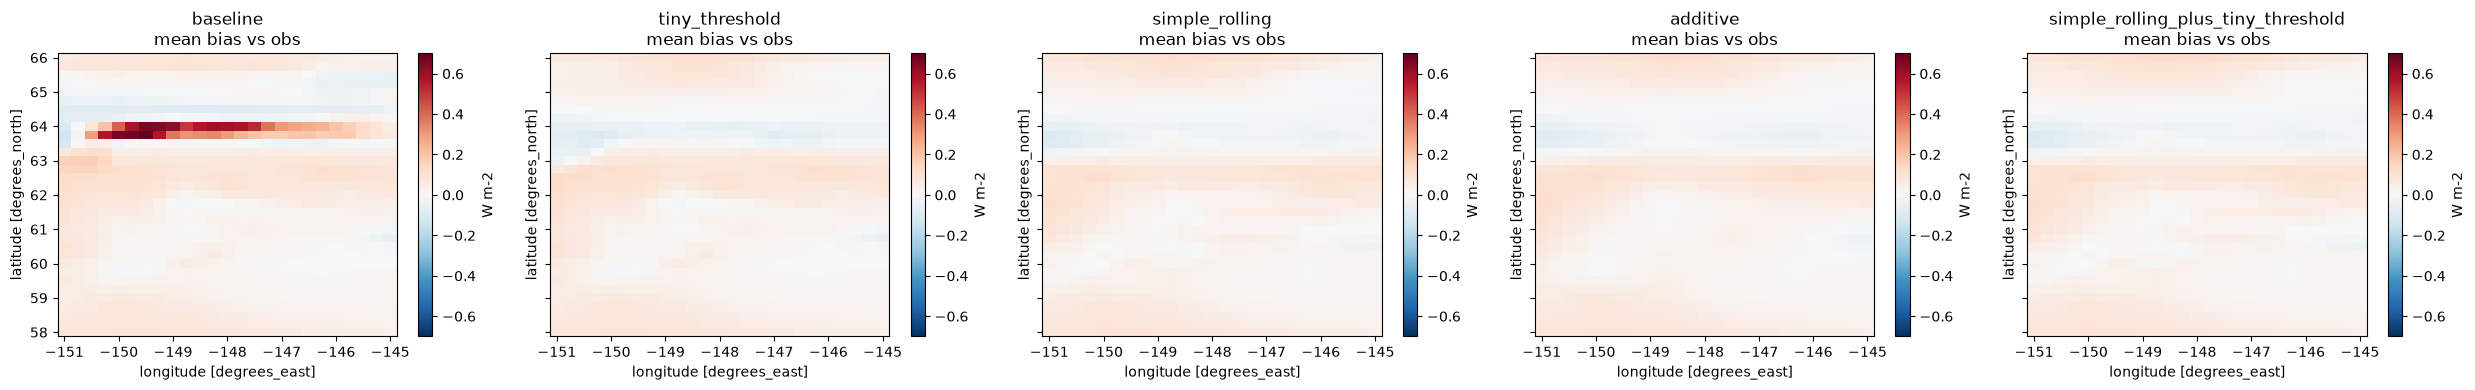

In [108]:
implausible_threshold = 3 * float(obs_fine_roi.max())
print(f"Implausible-value threshold ({VARIABLE}): {implausible_threshold:.6g} (raw units)")

mean_bias_maps = {
    name: (results_hist_roi[name].mean("time") - obs_fine_roi.mean("time")) * PLOT_SCALE
    for name in METHOD_NAMES
}
mean_bias_vmax = max(float(abs(m).max()) for m in mean_bias_maps.values())

fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
for ax, name in zip(axes, METHOD_NAMES):
    mean_bias_maps[name].plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=-mean_bias_vmax,
        vmax=mean_bias_vmax,
        cbar_kwargs={"label": PLOT_UNITS_LABEL},
    )
    ax.set_title(f"{name}\nmean bias vs obs")
plt.tight_layout()

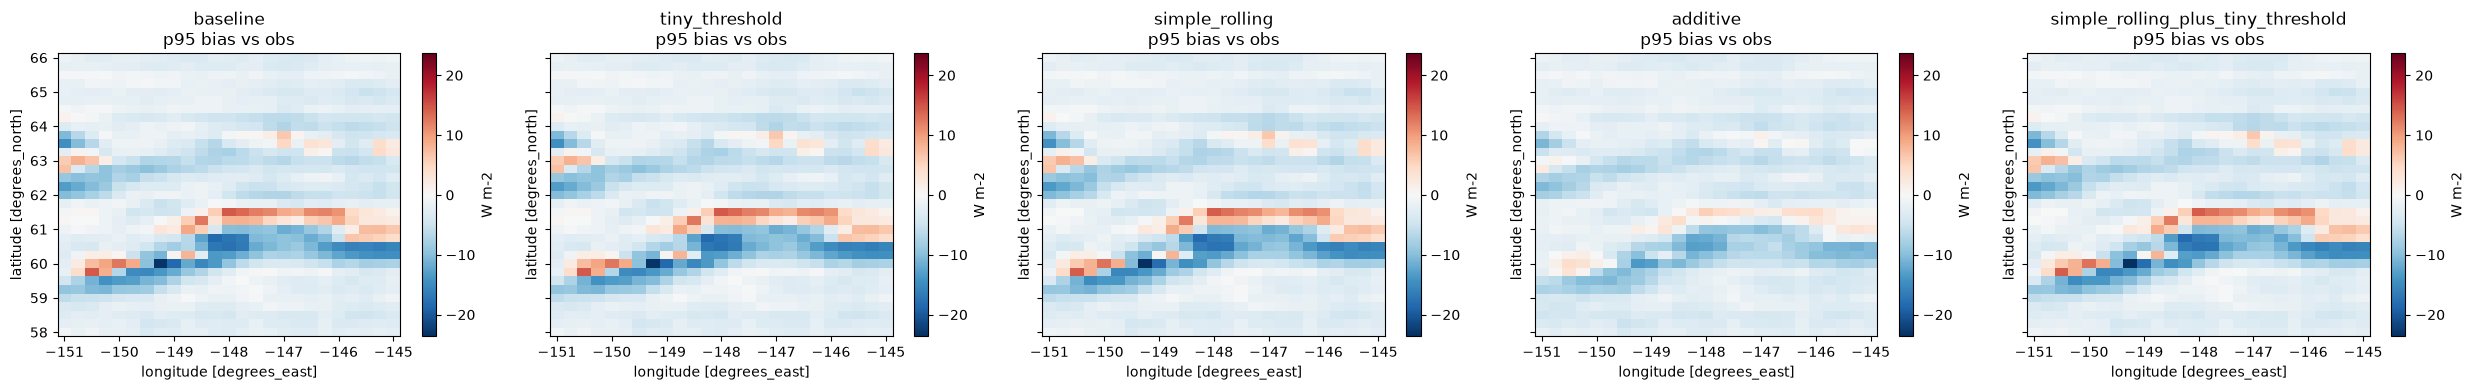

In [109]:
obs_p95 = obs_fine_roi.quantile(0.95, dim="time")
p95_bias_maps = {
    name: (results_hist_roi[name].quantile(0.95, dim="time") - obs_p95) * PLOT_SCALE
    for name in METHOD_NAMES
}
p95_bias_vmax = max(float(abs(m).max()) for m in p95_bias_maps.values())

fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
for ax, name in zip(axes, METHOD_NAMES):
    p95_bias_maps[name].plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=-p95_bias_vmax,
        vmax=p95_bias_vmax,
        cbar_kwargs={"label": PLOT_UNITS_LABEL},
    )
    ax.set_title(f"{name}\np95 bias vs obs")
plt.tight_layout()

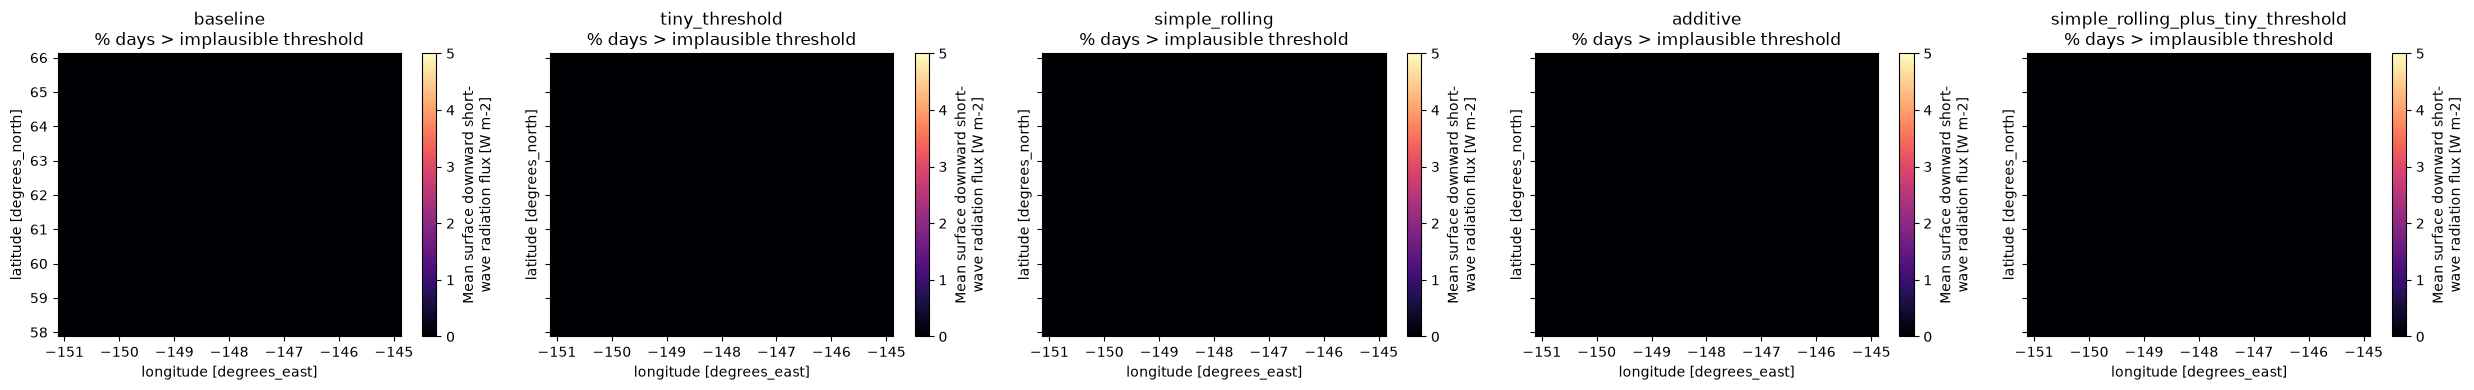

In [110]:
fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
for ax, name in zip(axes, METHOD_NAMES):
    frac_implausible = (results_hist_roi[name] > implausible_threshold).mean("time") * 100
    frac_implausible.plot(ax=ax, vmin=0, vmax=5, cmap="magma")
    ax.set_title(f"{name}\n% days > implausible threshold")
plt.tight_layout()

## Diagnostic 1b — does each method reproduce realistic day-to-day variability, everywhere?

The single-point time-series check (Diagnostic 2b, below) can show a method's output looking
disconnected from the actual day-to-day GCM/obs signal — e.g. `additive` failing to reproduce a
storm peak while staying implausibly elevated on actual dry days — but that's only ever one
hand-picked cell. This diagnostic scans the whole domain: at every fine grid cell, the ratio of
that method's own historical temporal standard deviation to obs_fine's. A ratio far from 1
(either direction) means that cell's day-to-day variability doesn't look like real weather —
too muted (values clustering near a smoothed mean, like `additive`'s coarse-anomaly transplant
with no local rescaling) or too wild (spurious extra variance from a blow-up). This is what would
have caught "the climatology was weird at multiple points" without relying on eyeballing one plot.

RMSE of (temporal std ratio - 1) across the domain, by method (0 = perfectly realistic
variability everywhere; large = many cells over- or under-shooting real day-to-day range):
  baseline        : 0.01769
  tiny_threshold  : 0.01757
  simple_rolling  : 0.01755
  additive        : 0.01402
  simple_rolling_plus_tiny_threshold: 0.01755


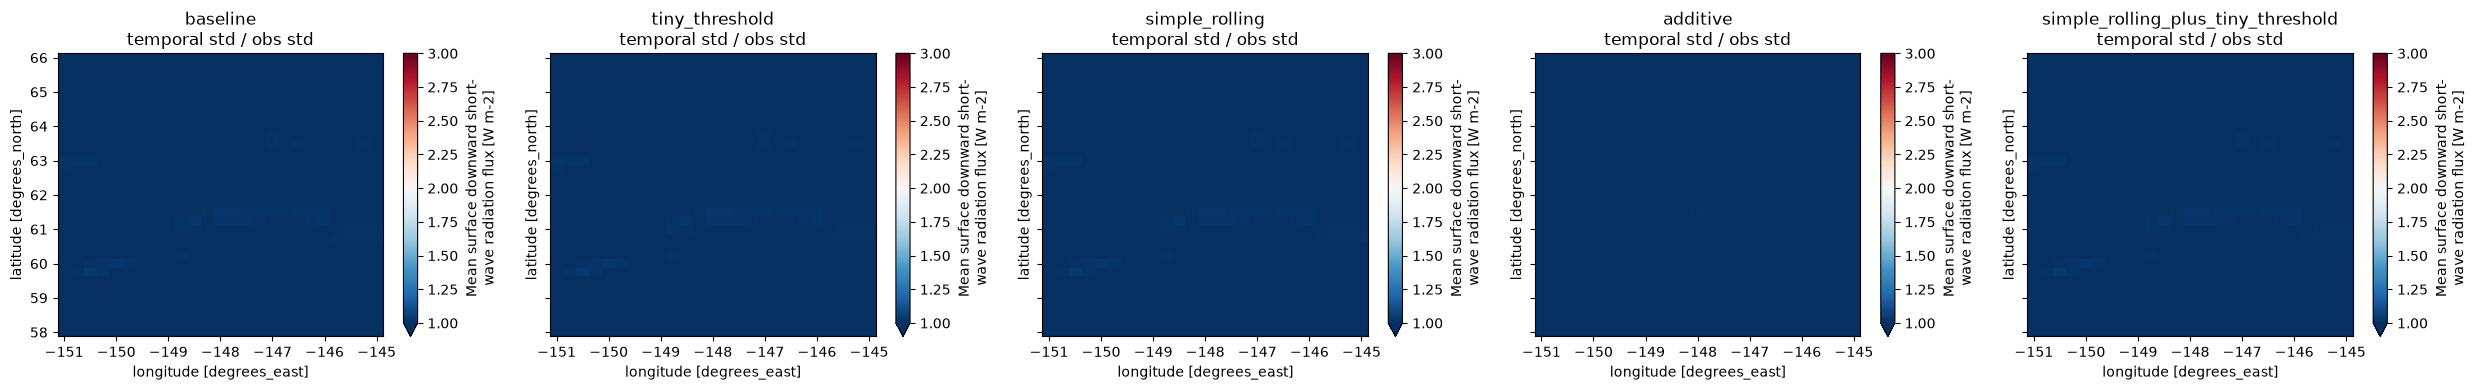

In [111]:
fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
obs_std = obs_fine_roi.std("time")
std_ratio_maps = {}
for ax, name in zip(axes, METHOD_NAMES):
    std_ratio = results_hist_roi[name].std("time") / obs_std
    std_ratio_maps[name] = std_ratio
    std_ratio.plot(ax=ax, cmap="RdBu_r", vmin=0, vmax=2, center=1)
    ax.set_title(f"{name}\ntemporal std / obs std")
plt.tight_layout()

std_ratio_rmse = {
    name: float(((std_ratio_maps[name] - 1) ** 2).mean() ** 0.5) for name in METHOD_NAMES
}
print("RMSE of (temporal std ratio - 1) across the domain, by method (0 = perfectly realistic")
print("variability everywhere; large = many cells over- or under-shooting real day-to-day range):")
for name, v in std_ratio_rmse.items():
    print(f"  {name:16s}: {v:.4g}")

## Diagnostic 1c — does any method fabricate a spike, at every point's own dark season?

Generalizes `issue_point_spike` (Diagnostic 2b, below) from the one hand-picked point to every
cell in the domain: at each fine grid cell independently, find *that cell's own* bottom-decile
climatology days (its own darkest/driest season — same logic as Diagnostic 2b, just run
per-cell instead of at one point), then compare each method's max value during that cell's own
season against obs_fine's own max during that same season, at that same cell. A method that
fabricates values beyond anything ever observed shows up as a hot spot here, wherever in the
domain that happens — not just at whichever single point Diagnostic 2 happened to auto-detect.

RMSE of the own-season spike across the domain, by method (0 = never exceeds what's ever
been observed in that cell's own dark season; large = fabricating spikes widely):
  baseline        : 3.857 W m-2
  tiny_threshold  : 1.064 W m-2
  simple_rolling  : 0.8474 W m-2
  additive        : 0.8746 W m-2
  simple_rolling_plus_tiny_threshold: 0.8474 W m-2


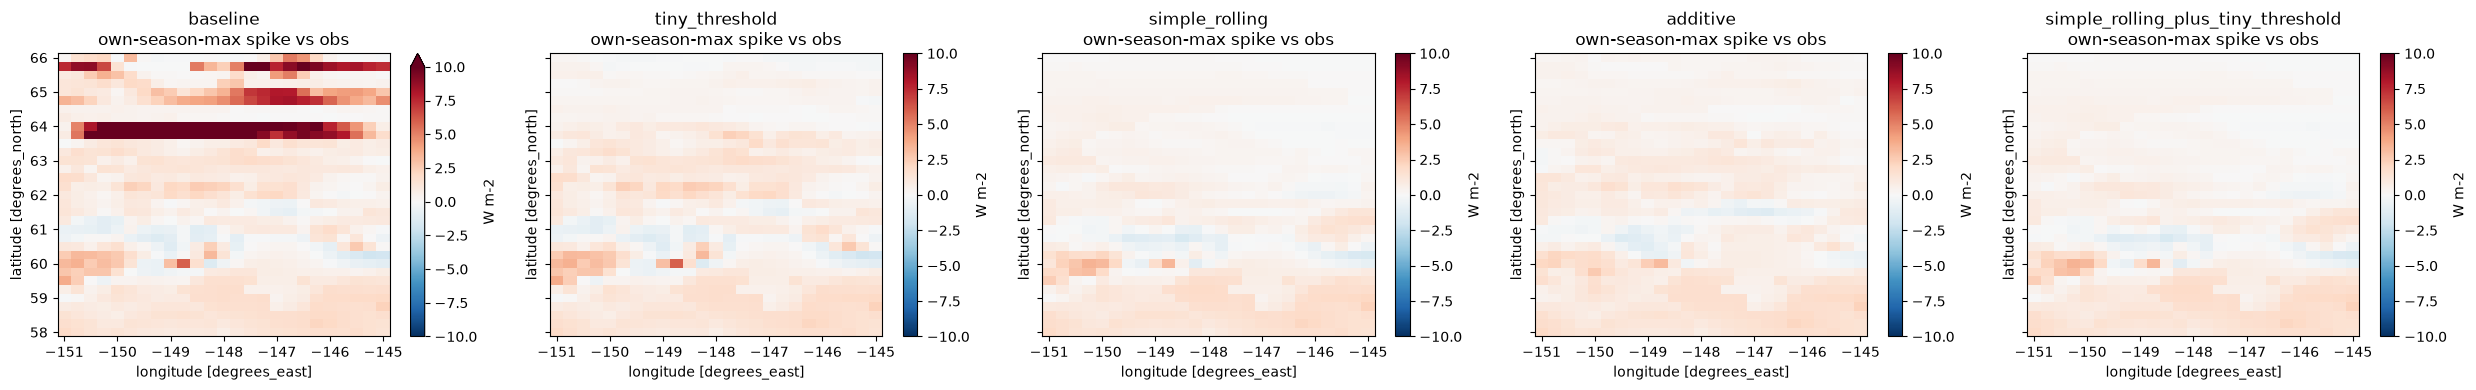

In [117]:
clim_doy_map = obs_fine_roi.groupby("time.dayofyear").mean("time")
season_cutoff_map = clim_doy_map.quantile(0.1, dim="dayofyear")
low_clim_mask_map = (clim_doy_map <= season_cutoff_map).sel(
    dayofyear=obs_fine_roi["time.dayofyear"]
)
reference_max_map = obs_fine_roi.where(low_clim_mask_map).max("time")

spike_maps = {
    name: (results_hist_roi[name].where(low_clim_mask_map).max("time") - reference_max_map)
    * PLOT_SCALE
    for name in METHOD_NAMES
}
spike_vmax = max(float(abs(m).max()) for m in spike_maps.values())
spike_vmax = 10

fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
for ax, name in zip(axes, METHOD_NAMES):
    spike_maps[name].plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=-spike_vmax,
        vmax=spike_vmax,
        cbar_kwargs={"label": PLOT_UNITS_LABEL},
    )
    ax.set_title(f"{name}\nown-season-max spike vs obs")
plt.tight_layout()

spike_magnitude_rmse = {name: float((spike_maps[name] ** 2).mean() ** 0.5) for name in METHOD_NAMES}
print("RMSE of the own-season spike across the domain, by method (0 = never exceeds what's ever")
print("been observed in that cell's own dark season; large = fabricating spikes widely):")
for name, v in spike_magnitude_rmse.items():
    print(f"  {name:16s}: {v:.4g} {PLOT_UNITS_LABEL}")

## Diagnostic 1d — does any method produce physically impossible negative values?

rsds cannot be negative. `allow_negative_values=False` (used for `baseline`/
`tiny_threshold`/`simple_rolling`, matching production) only clips the *smoothed climatology*
to zero inside `calculate_doy_means` — it does **not** clip the final `residuals + climatology`
sum for either disaggregation formulation, so a negative final value is possible for any of the
four methods in principle. `additive` runs with `allow_negative_values=True` specifically so
this check measures the true, unsuppressed extent of the problem for it, rather than a version
partly masked by a setting that was never actually about the final output.

Negative-value summary, by method:
  baseline        : 0% of (cell, day) values negative, min value = 0 W m-2
  tiny_threshold  : 0% of (cell, day) values negative, min value = 0.1778 W m-2
  simple_rolling  : 0% of (cell, day) values negative, min value = 0.06376 W m-2
  additive        : 0.0004664% of (cell, day) values negative, min value = -1.521 W m-2
  simple_rolling_plus_tiny_threshold: 0% of (cell, day) values negative, min value = 0.1326 W m-2


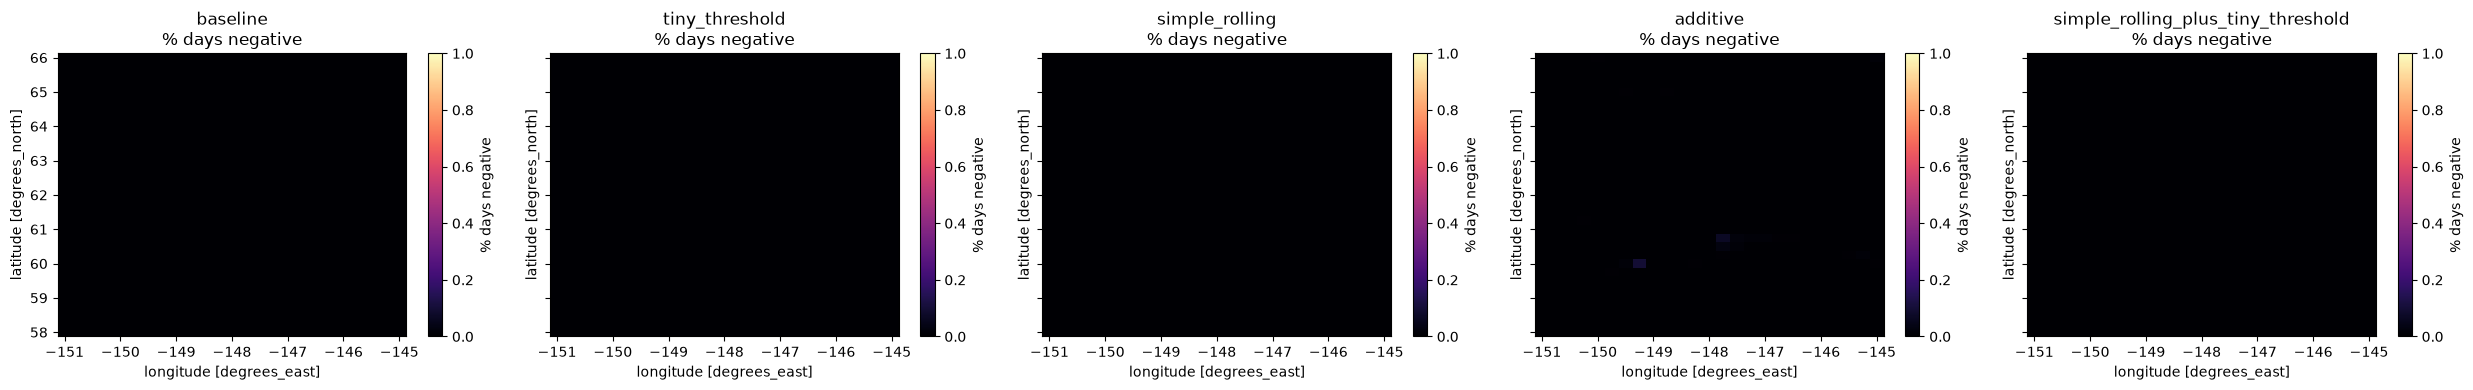

In [113]:
neg_maps = {name: (results_hist_roi[name] < 0).mean("time") * 100 for name in METHOD_NAMES}
neg_vmax = max(1.0, max(float(m.max()) for m in neg_maps.values()))

fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
for ax, name in zip(axes, METHOD_NAMES):
    neg_maps[name].plot(
        ax=ax, vmin=0, vmax=neg_vmax, cmap="magma", cbar_kwargs={"label": "% days negative"}
    )
    ax.set_title(f"{name}\n% days negative")
plt.tight_layout()

pct_negative = {}
min_value = {}
print("Negative-value summary, by method:")
for name in METHOD_NAMES:
    arr = results_hist_roi[name]
    pct_negative[name] = float((arr < 0).mean()) * 100
    min_value[name] = float(arr.min()) * PLOT_SCALE
    print(
        f"  {name:16s}: {pct_negative[name]:.4g}% of (cell, day) values negative, "
        f"min value = {min_value[name]:.4g} {PLOT_UNITS_LABEL}"
    )

## Diagnostic 2 — day-of-year detail at the most-affected cell

Auto-detects the grid cell where the `baseline` run departs most from `simple_rolling`
(a proxy for "where the blow-up is worst"), then plots raw day-of-year scatter for every
method plus obs at that single point — the same view used in the exploratory version of
this notebook, just picked programmatically instead of by hand.

Most-affected cell: lat=63.000, lon=-147.000


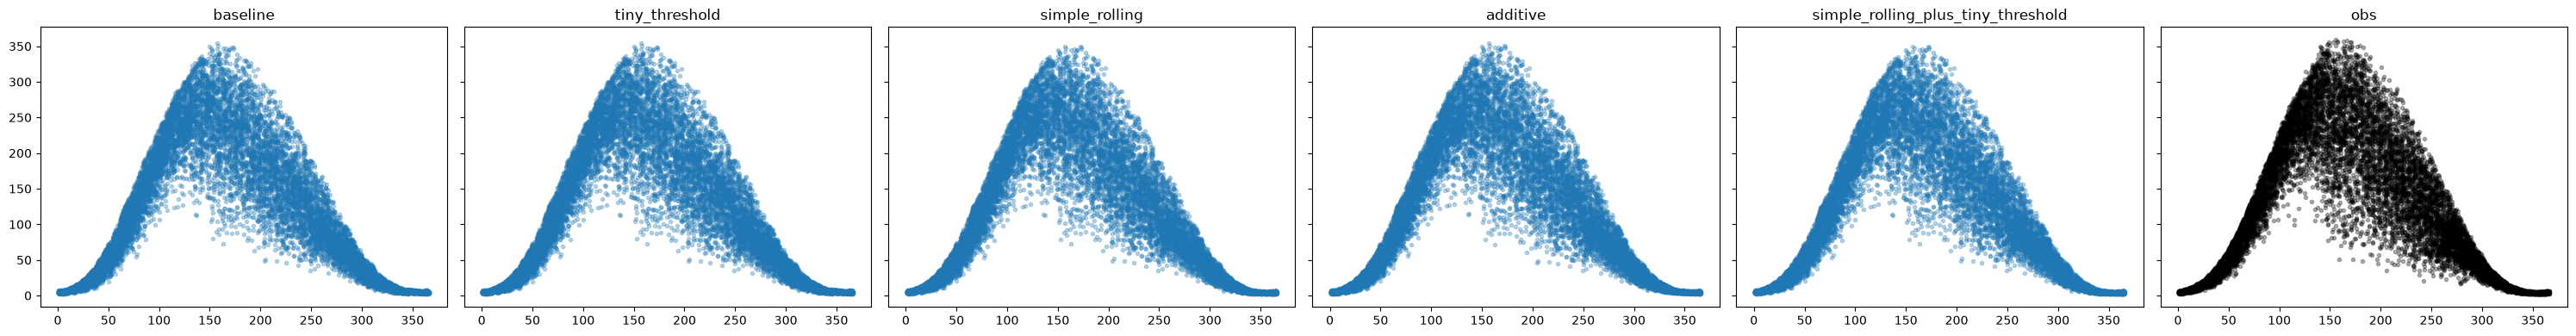

In [114]:
blowup_diff = (
    results_hist_roi["baseline"].max("time") - results_hist_roi["simple_rolling"].max("time")
).compute()
worst = blowup_diff.where(blowup_diff == blowup_diff.max(), drop=True)
POINT_LAT = float(worst["lat"][0])
POINT_LON = float(worst["lon"][0])
print(f"Most-affected cell: lat={POINT_LAT:.3f}, lon={POINT_LON:.3f}")

fig, axes = plt.subplots(
    1, len(METHOD_NAMES) + 1, figsize=(5 * (len(METHOD_NAMES) + 1), 4), sharey=True
)
for ax, name in zip(axes, METHOD_NAMES):
    pt = results_hist_roi[name].sel(lat=POINT_LAT, lon=POINT_LON, method="nearest")
    ax.plot(pt["time.dayofyear"], pt * PLOT_SCALE, ".", alpha=0.3)
    ax.set_title(name)
obs_pt = obs_fine_roi.sel(lat=POINT_LAT, lon=POINT_LON, method="nearest")
axes[len(METHOD_NAMES)].plot(obs_pt["time.dayofyear"], obs_pt * PLOT_SCALE, ".k", alpha=0.3)
axes[len(METHOD_NAMES)].set_title("obs")
plt.tight_layout()

## Diagnostic 2b — direct chronological check against raw GCM + obs

Diagnostic 2 shows each method's *own* day-of-year climatology shape in isolation. This cell
instead overlays, on one shared time axis for one representative year: the **raw** (pre-bias-
correction) coarse GCM historical output (`model_hist`), the **coarsened observations**
(`obs_coarse`), fine-resolution obs, and each method's disaggregated output — at a single
point, restricted to that point's own bottom-decile-climatology season (identified below). This reproduces the exact point/season reported in [issue #547](https://github.com/carbonplan/srm-downscaling/issues/547).

This is the shape of evidence that actually diagnoses a blow-up: if `model_hist` and both obs
series sit near zero through the season while a method's disaggregated output spikes well
above them, that method is fabricating signal the GCM never produced — not preserving it.
Diagnostic 2's per-method DOY-scatter panels don't make that comparison directly (no
raw-GCM/obs-coarse overlay, no explicit season restriction), so they could miss this even
though the blow-up is visible here.

Using known-issue point: lat=64, lon=-149
Climatology range at this point: 2.191 to 257.5 W m-2 (TINY_THRESHOLD_DEFAULT = 1.0 W m-2, a raw-unit value — not directly comparable to the scaled range above)
Bottom-decile cutoff: 4.502 W m-2
Low-climatology days-of-year at this point: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(338.0), np.float64(339.0), np.float64(340.0), np.float64(341.0), np.float64(342.0), np.float64(343.0), np.float64(344.0), np.float64(345.0), np.float64(346.0), np.float64(347.0), np.float64(348.0), np.float64(349.0), np.float64(350.0), np.float64(351.0), np.float64(352.0), np.float64(353.0), np.float64(354.0), np.float64(355.0), np.float64(356.0), np.float64(357.0), np.float64(358.0), np.float64(359.0), np.float64(360.0), np.float64(361.0), np.float64(362.0), np.float64(363.0), np.float64(364.0), np.float64(365.0), np.float64(366.0)]


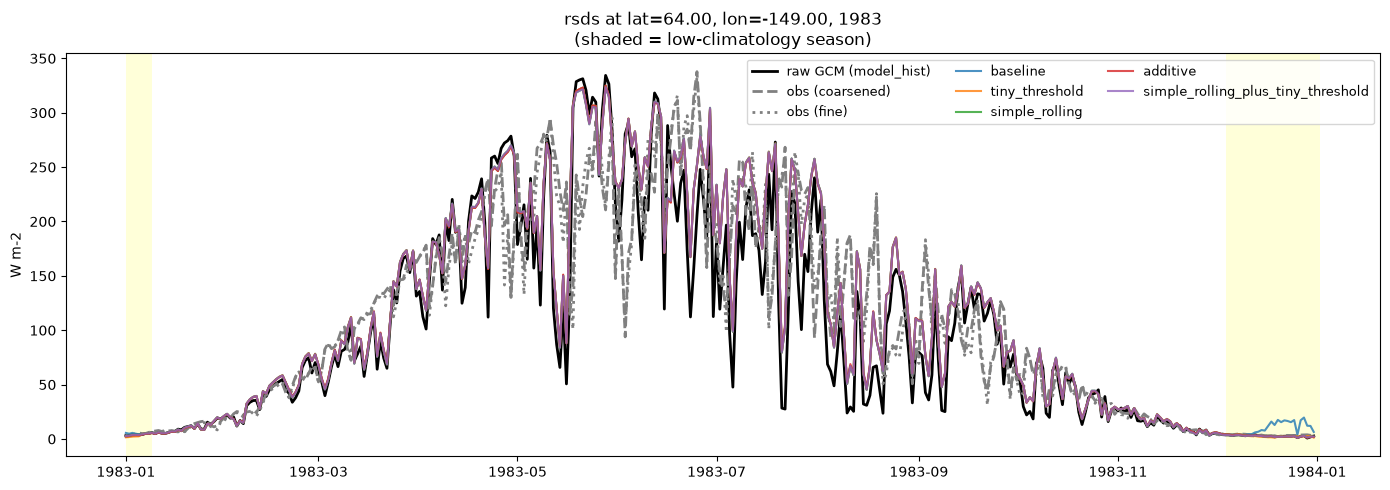

In [115]:
# Known reported case: issue #547 (https://github.com/carbonplan/srm-downscaling/issues/547)
ISSUE_POINT_LAT, ISSUE_POINT_LON = 64, -149
CHECK_LAT, CHECK_LON = ISSUE_POINT_LAT, ISSUE_POINT_LON
print(f"Using known-issue point: lat={CHECK_LAT}, lon={CHECK_LON}")

# Identify this point's own darkest/driest season: the bottom decile of its annual climatology
# cycle. Deliberately NOT `< TINY_THRESHOLD_DEFAULT` — that's a production clipping threshold
# tuned domain-wide, and a specific point's actual climatology minimum can sit above it (e.g.
# issue #547 describes "<5 W/m2", well above rsds's tiny_threshold of 1.0 W/m2) while still
# being the point's own near-zero season worth inspecting for a blow-up.
clim_at_point = (
    obs_fine_roi.sel(lat=CHECK_LAT, lon=CHECK_LON, method="nearest")
    .groupby("time.dayofyear")
    .mean("time")
    .compute()
)
print(
    f"Climatology range at this point: {float(clim_at_point.min()) * PLOT_SCALE:.4g} to "
    f"{float(clim_at_point.max()) * PLOT_SCALE:.4g} {PLOT_UNITS_LABEL} "
    f"(TINY_THRESHOLD_DEFAULT = {TINY_THRESHOLD_DEFAULT} {UNITS_LABEL}, a raw-unit value —"
    " not directly comparable to the scaled range above)"
)
season_cutoff = float(clim_at_point.quantile(0.1))
low_clim_doys = clim_at_point["dayofyear"].where(clim_at_point <= season_cutoff, drop=True).values
print(f"Bottom-decile cutoff: {season_cutoff * PLOT_SCALE:.4g} {PLOT_UNITS_LABEL}")
print(f"Low-climatology days-of-year at this point: {sorted(low_clim_doys)}")

PLOT_YEAR = TRAIN_PERIOD_START + 5  # a full, unclipped training year for a clean 12-month window
time_window = slice(f"{PLOT_YEAR}-01-01", f"{PLOT_YEAR}-12-31")

fig, ax = plt.subplots(figsize=(14, 5))
raw_pt = model_hist.sel(lat=CHECK_LAT, lon=CHECK_LON, method="nearest").sel(time=time_window)
obs_coarse_pt = obs_coarse.sel(lat=CHECK_LAT, lon=CHECK_LON, method="nearest").sel(time=time_window)
obs_fine_pt = obs_fine_roi.sel(lat=CHECK_LAT, lon=CHECK_LON, method="nearest").sel(time=time_window)
ax.plot(raw_pt["time"], raw_pt * PLOT_SCALE, "-", color="black", lw=2, label="raw GCM (model_hist)")
ax.plot(
    obs_coarse_pt["time"],
    obs_coarse_pt * PLOT_SCALE,
    "--",
    color="gray",
    lw=2,
    label="obs (coarsened)",
)
ax.plot(obs_fine_pt["time"], obs_fine_pt * PLOT_SCALE, ":", color="gray", lw=2, label="obs (fine)")
for name in METHOD_NAMES:
    m_pt = (
        results_hist_roi[name]
        .sel(lat=CHECK_LAT, lon=CHECK_LON, method="nearest")
        .sel(time=time_window)
    )
    ax.plot(m_pt["time"], m_pt * PLOT_SCALE, alpha=0.8, label=name)
for doy in low_clim_doys:
    ax.axvspan(
        np.datetime64(f"{PLOT_YEAR}-01-01") + np.timedelta64(int(doy) - 1, "D"),
        np.datetime64(f"{PLOT_YEAR}-01-01") + np.timedelta64(int(doy), "D"),
        color="yellow",
        alpha=0.15,
        lw=0,
    )
ax.set_ylabel(PLOT_UNITS_LABEL)
ax.set_title(
    f"{VARIABLE} at lat={CHECK_LAT:.2f}, lon={CHECK_LON:.2f}, {PLOT_YEAR}\n(shaded = low-climatology season)"
)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()

### Quantify the spike, over the full historical record (not just the plotted year)

Turns the plot above into a number that actually feeds the final ranking below: at
`(CHECK_LAT, CHECK_LON)`, restricted to the low-climatology days-of-year identified above,
take the largest value any reference series (raw GCM, coarsened obs, fine obs) ever reaches
across the whole historical record, then for each method compute how far its own max exceeds
that reference — a large positive number is exactly the issue #547 failure mode: the method
inventing a value none of the raw inputs ever came close to, at the specific point/season where
it was reported.

In [118]:
if len(low_clim_doys) == 0:
    raise ValueError(
        f"No low-climatology days found at lat={CHECK_LAT}, lon={CHECK_LON} "
        "(the point's own annual climatology cycle is flat, so no bottom-decile season exists). "
        "Check that this point actually falls on a valid, non-masked obs_fine cell."
    )


def _season_max(da_full, label):
    pt = da_full.sel(lat=CHECK_LAT, lon=CHECK_LON, method="nearest")
    value = float(pt.where(pt["time.dayofyear"].isin(low_clim_doys)).max())
    print(
        f"  {label:16s} season max: {value * PLOT_SCALE if not np.isnan(value) else value:.4g} {PLOT_UNITS_LABEL}"
    )
    return value


print("Per-series season max at this point (NaN means no low-climatology day overlapped that")
print("series' own time/calendar — e.g. model_hist's calendar can shift dayofyear numbering):")
reference_season_max = np.nanmax(
    [
        _season_max(model_hist, "model_hist"),
        _season_max(obs_coarse, "obs_coarse"),
        _season_max(obs_fine_roi, "obs_fine"),
    ]
)
print(
    f"Reference (raw GCM / obs) season max at this point: {reference_season_max * PLOT_SCALE:.4g} {PLOT_UNITS_LABEL}"
)

point_spike_magnitude = {
    name: (_season_max(results_hist_roi[name], name) - reference_season_max) * PLOT_SCALE
    for name in METHOD_NAMES
}
print("Spike magnitude by method (method's season max minus reference season max; 0 = no spike):")
for name, v in point_spike_magnitude.items():
    print(f"  {name:16s}: {v:+.4g} {PLOT_UNITS_LABEL}")

Per-series season max at this point (NaN means no low-climatology day overlapped that
series' own time/calendar — e.g. model_hist's calendar can shift dayofyear numbering):
  model_hist       season max: 6.829 W m-2
  obs_coarse       season max: 7.125 W m-2
  obs_fine         season max: 6.132 W m-2
Reference (raw GCM / obs) season max at this point: 7.125 W m-2
  baseline         season max: 25.09 W m-2
  tiny_threshold   season max: 7.077 W m-2
  simple_rolling   season max: 6.394 W m-2
  additive         season max: 6.727 W m-2
  simple_rolling_plus_tiny_threshold season max: 6.394 W m-2
Spike magnitude by method (method's season max minus reference season max; 0 = no spike):
  baseline        : +17.96 W m-2
  tiny_threshold  : -0.04711 W m-2
  simple_rolling  : -0.7302 W m-2
  additive        : -0.3974 W m-2
  simple_rolling_plus_tiny_threshold: -0.7302 W m-2


## Diagnostic 3 — preservation of the GCM's projected change signal

One reference, shared by all four methods — and it has to be the multiplicative formulation,
not a naive additive-style absolute-delta regrid. Precipitation and rsds changes scale with
local magnitude (multiplicative is production's own choice for rsds, not
arbitrary): the physically appropriate assumption is that the coarse-implied *fractional*
change applies uniformly, so a fine pixel's absolute change should scale with that pixel's own
climatological mean. A reference built the additive way (uniform absolute change everywhere)
would make `additive` look artificially good by construction — comparing it to itself — instead
of exposing that it doesn't do this rescaling at all.

"Raw GCM-implied delta" is therefore: take the coarse debiased ratio (scenario mean / historical
mean, at coarse resolution — no clim_method or threshold choice enters this), regrid that ratio
to the fine grid, and apply it to each fine pixel's own **observed** historical mean. Every
method's actual fine-resolution delta is then diffed against this one common reference: a large
deviation means that method's disaggregation choices are distorting the change signal relative
to what local ratio-rescaling implies — including `additive`, which should now show up badly
wherever fine-vs-coarse climatology diverge, since it doesn't rescale at all.

0 non-finite coarse_ratio cells (of 40) — from a near-zero or
zero coarse historical mean; masked to NaN below so they're excluded, not propagated as inf.
Coarse ratio range (finite cells only): 0.9817 to 1.023


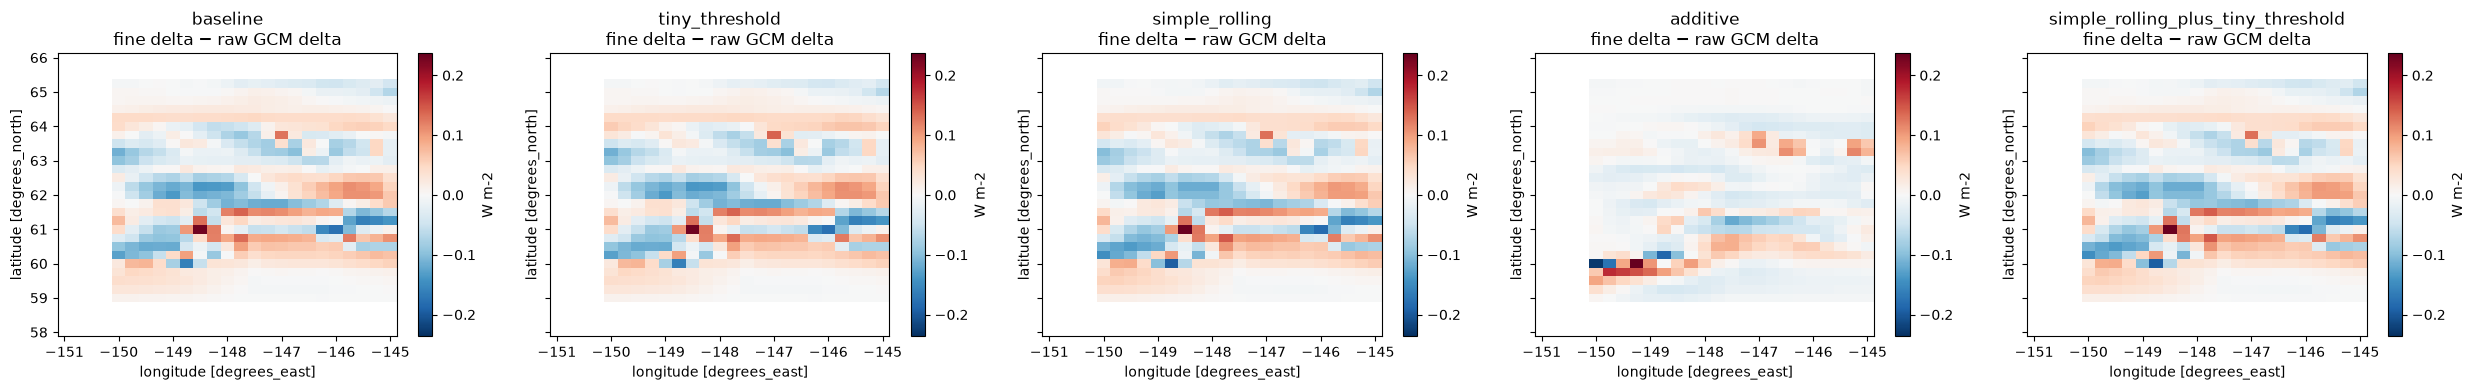

In [119]:
coarse_ratio = debiased_coarse_scenario_roi.mean("time") / debiased_coarse_hist_roi.mean("time")
n_bad = int((~np.isfinite(coarse_ratio)).sum())
print(f"{n_bad} non-finite coarse_ratio cells (of {coarse_ratio.size}) — from a near-zero or")
print(
    "zero coarse historical mean; masked to NaN below so they're excluded, not propagated as inf."
)
coarse_ratio = coarse_ratio.where(np.isfinite(coarse_ratio))
print(
    f"Coarse ratio range (finite cells only): {float(coarse_ratio.min()):.4g} to {float(coarse_ratio.max()):.4g}"
)
coarse_ratio_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=coarse_ratio, da_fine_grid=obs_fine_roi
)
raw_delta_fine = (coarse_ratio_fine - 1) * obs_fine_roi.mean("time")

method_deltas = {
    name: results_scenario_roi[name].mean("time") - results_hist_roi[name].mean("time")
    for name in METHOD_NAMES
}
distortion_maps = {
    name: (method_deltas[name] - raw_delta_fine) * PLOT_SCALE for name in METHOD_NAMES
}
distortion_vmax = max(float(abs(m).max()) for m in distortion_maps.values())

fig, axes = plt.subplots(1, len(METHOD_NAMES), figsize=(5 * len(METHOD_NAMES), 4), sharey=True)
for ax, name in zip(axes, METHOD_NAMES):
    distortion_maps[name].plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=-distortion_vmax,
        vmax=distortion_vmax,
        cbar_kwargs={"label": PLOT_UNITS_LABEL},
    )
    ax.set_title(f"{name}\nfine delta − raw GCM delta")
plt.tight_layout()

## Diagnostic 4 — how much of the day-specific GCM signal does each fix discard?

`tiny_threshold` doesn't just clip a ratio — on days where the fine-resolution obs climatology
is below threshold, it **replaces** the disaggregated value outright with the flat, unsmoothed
domain climatology (`downscaling_utils.py:796-809`), discarding that day's GCM-specific signal
entirely. `simple_rolling` never overrides anything; it only smooths the climatology baseline
that the (still day-specific) residual gets multiplied back onto. This cell quantifies how much
of the record `tiny_threshold` actually overrides, and compares the variance that survives on
those specific days across methods — a direct measure of signal loss, not just visual bias.

In [120]:
tiny_fine_mask = obs_fine_roi.groupby("time.dayofyear").mean("time") < TINY_THRESHOLD_DEFAULT
override_frac = float(tiny_fine_mask.mean()) * 100
print(
    f"Fraction of (cell, day-of-year) climatology values below tiny_threshold: {override_frac:.2f}%"
)
print(
    "(this is the share of the record where tiny_threshold overrides the GCM's day-specific signal;"
)
print(
    " simple_rolling overrides nothing by construction, so this number is specific to tiny_threshold.)"
)

tiny_mask_on_time = tiny_fine_mask.sel(dayofyear=obs_fine_roi["time.dayofyear"])
variance_on_tiny_days = {
    name: float(results_hist_roi[name].where(tiny_mask_on_time).var("time").mean())
    for name in METHOD_NAMES
}
print("Mean temporal variance on tiny-climatology days, by method (lower = more signal discarded):")
for name, v in variance_on_tiny_days.items():
    print(f"  {name:16s}: {v:.6g}")

Fraction of (cell, day-of-year) climatology values below tiny_threshold: 0.92%
(this is the share of the record where tiny_threshold overrides the GCM's day-specific signal;
 simple_rolling overrides nothing by construction, so this number is specific to tiny_threshold.)
Mean temporal variance on tiny-climatology days, by method (lower = more signal discarded):
  baseline        : 0.527102
  tiny_threshold  : 0.0259337
  simple_rolling  : 0.0462176
  additive        : 0.0501671
  simple_rolling_plus_tiny_threshold: 0.0518966


## Summary metrics table

In [121]:
summary_rows = []
for name in METHOD_NAMES:
    mean_bias = float(
        ((results_hist_roi[name].mean("time") - obs_fine_roi.mean("time")) ** 2).mean() ** 0.5
    )
    p95_bias = float(
        (
            (
                results_hist_roi[name].quantile(0.95, dim="time")
                - obs_fine_roi.quantile(0.95, dim="time")
            )
            ** 2
        ).mean()
        ** 0.5
    )
    implausible_pct = float((results_hist_roi[name] > implausible_threshold).mean()) * 100
    delta_rmse = float(((method_deltas[name] - raw_delta_fine) ** 2).mean() ** 0.5)
    summary_rows.append(
        dict(
            method=name,
            mean_bias_rmse=mean_bias,
            p95_bias_rmse=p95_bias,
            pct_implausible_days=implausible_pct,
            gcm_delta_distortion_rmse=delta_rmse,
            variance_on_tiny_days=variance_on_tiny_days[name],
            issue_point_spike=point_spike_magnitude[name],
            spike_magnitude_rmse=spike_magnitude_rmse[name],
            std_ratio_rmse=std_ratio_rmse[name],
            pct_negative=pct_negative[name],
        )
    )
summary = pd.DataFrame(summary_rows).set_index("method")
summary

,mean_bias_rmse,p95_bias_rmse,pct_implausible_days,gcm_delta_distortion_rmse,variance_on_tiny_days,issue_point_spike,spike_magnitude_rmse,std_ratio_rmse,pct_negative
method,,,,,,,,,
baseline,0.109079,5.485377,0.0,0.056061,0.527102,17.961065,3.857387,0.017687,0.000000
tiny_threshold,0.053572,5.485377,0.0,0.056176,0.025934,-0.047110,1.064283,0.017574,0.000000
simple_rolling,0.051119,5.486231,0.0,0.056438,0.046218,-0.730169,0.847365,0.017547,0.000000
additive,0.051609,4.293700,0.0,0.037516,0.050167,-0.397430,0.874580,0.014015,0.000466
simple_rolling_plus_tiny_threshold,0.051977,5.486231,0.0,0.056419,0.051897,-0.730169,0.847365,0.017551,0.000000


## Automated data-driven verdict — differences from baseline, in native units

An earlier version of this cell z-scored each metric across the methods (`(value − mean) /
std`). That's the wrong tool here: z-scoring divides by *how spread out these particular
methods happen to be on this metric* — so if all five methods are genuinely close together on
a metric (a real, common case — see `p95_bias_rmse`/`std_ratio_rmse` above, which barely move
between methods), z-scoring still manufactures a full ±1.5-ish spread out of what's actually
noise-level variation, because it's normalizing by a tiny denominator. It can't tell "these
differ by a meaningless amount" apart from "these differ by a lot," since both get stretched
to the same z-scale by construction.

Instead: show each method's difference from `baseline` directly, in that metric's own native
units (positive = better than doing nothing, negative = worse, magnitude is the actual physical
size of the difference) — nothing here is normalized by the methods' own spread, so a metric
where they're genuinely all close together correctly shows small numbers instead of an inflated
spread. A separate relative-spread check below flags, per metric, whether the methods are
meaningfully differentiated at all or effectively tied, using each metric's own largest observed
magnitude as the yardstick (not the tiny cross-method variation) — so a metric that's genuinely
flat across methods gets called out as flat, not stretched into a false signal.

`issue_point_spike` (the single-point version from Diagnostic 2b, tied to the exact reported
issue location) stays in the summary table for narrative context but is left out here —
`spike_magnitude_rmse` is the domain-wide version of the same idea.

In [107]:
obs_realism_cols = [
    "mean_bias_rmse",
    "p95_bias_rmse",
    "pct_implausible_days",
    "spike_magnitude_rmse",
    "std_ratio_rmse",
    "pct_negative",
]
comparison_cols = obs_realism_cols + ["gcm_delta_distortion_rmse"]

improvement_over_baseline = summary.loc["baseline", comparison_cols] - summary[comparison_cols]
print("Improvement over baseline, in each metric's own native units")
print("(positive = better than doing nothing; near-zero = no real difference from baseline):")
print(improvement_over_baseline.round(4))

metric_range = summary[comparison_cols].max() - summary[comparison_cols].min()
metric_scale = summary[comparison_cols].abs().max().replace(0, np.nan)
relative_spread = (metric_range / metric_scale).fillna(0.0)
print("\nRelative spread across all methods, per metric (range / largest magnitude observed) —")
print("below ~10% means the methods are essentially tied here, not meaningfully different:")
for col in comparison_cols:
    tag = "MEANINGFUL SPREAD" if relative_spread[col] > 0.10 else "essentially tied"
    print(f"  {col:28s}: {relative_spread[col] * 100:5.1f}%  ({tag})")

TIE_TOL = 0.10  # same threshold as the relative-spread check above
print("\nBest method per metric (methods within 10% of the metric's own scale of the best value")
print("are called tied, rather than arbitrarily naming one winner):")
for col in comparison_cols:
    scale = metric_scale[col] if not np.isnan(metric_scale[col]) else 1.0
    best_val = summary[col].min()
    tied = summary.index[(summary[col] - best_val).abs() <= TIE_TOL * scale].tolist()
    if len(tied) > 1:
        print(f"  {col:28s}: tied — {', '.join(tied)}")
    else:
        print(f"  {col:28s}: {tied[0]}")

Improvement over baseline, in each metric's own native units
(positive = better than doing nothing; near-zero = no real difference from baseline):
                                    mean_bias_rmse  p95_bias_rmse  \
method                                                              
baseline                                    0.0000         0.0000   
tiny_threshold                              0.0555         0.0000   
simple_rolling                              0.0580        -0.0009   
additive                                    0.0575         1.1917   
simple_rolling_plus_tiny_threshold          0.0571        -0.0009   

                                    pct_implausible_days  \
method                                                     
baseline                                             0.0   
tiny_threshold                                       0.0   
simple_rolling                                       0.0   
additive                                             0.0   
simple_ro

## Your qualitative takeaway

_(Fill in after inspecting the plots above for rsds / Alaska. What do the DOY
scatter plots at the worst-affected cell actually look like — is `tiny_threshold`'s flat
override visibly implausible, or does it look like reasonable drizzle? Does `simple_rolling`
introduce its own artifacts, e.g. over-smoothing a real seasonal transition?)_